# Phase 1 - Load, Explore & Clean

In [1]:
# Note: Used an AI assistant (Claude) to help write and structure parts of this notebook.
# All code has been reviewed and understood by me.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/raw/train.csv")

print("Shape:", df.shape)        # (891, 12)
print(df.head())                 # First 5 rows
print(df.info())                 # Dtypes + non-null counts
print(df.describe())             # Summary stats


Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

The Titanic dataset has 891 rows and 12 columns. The target column is Survived (0 = died, 1 = survived). From the first 5 rows I can already see missing values in Cabin and Age columns. The Fare column has a max of 512 which is much higher than the median of ~14, suggesting outliers.

In [3]:
df["Survived"] = df["Survived"].astype("category")
df["Pclass"] = df["Pclass"].astype("category")
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")
print(df.dtypes)

PassengerId       int64
Survived       category
Pclass         category
Name                str
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Cabin               str
Embarked       category
dtype: object


Fix Data Types

Changed Survived and Pclass from numbers to category because they are labels (died/survived, class 1/2/3), not quantities you would do
  math on. Also changed Sex and Embarked to category since they only have a few unique values (male/female, C/Q/S) â€” this saves memory and
   tells pandas these are groups

-  Count missing values: `.isnull().sum()`
-  Find which columns have the most missing
-  Decide what to do for each: fill or drop
-  Explain WHY for each decision in a markdown cell

**Step 1 - See the damage:**

In [4]:
print(df.isnull().sum())
print((df.isnull().mean() * 100).round(1))

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId     0.0
Survived        0.0
Pclass          0.0
Name            0.0
Sex             0.0
Age            19.9
SibSp           0.0
Parch           0.0
Ticket          0.0
Fare            0.0
Cabin          77.1
Embarked        0.2
dtype: float64


**Step 2 - Make a summary function:** 


In [5]:
def missing_summary(df) : 
    total = df.isna().sum()
    pct = (df.isna().mean() * 100 )
    return (pd.DataFrame({"missing_count": total, "missing_percent": pct})
            .sort_values("missing_percent", ascending=False))

print(missing_summary(df))

             missing_count  missing_percent
Cabin                  687        77.104377
Age                    177        19.865320
Embarked                 2         0.224467
PassengerId              0         0.000000
Name                     0         0.000000
Pclass                   0         0.000000
Survived                 0         0.000000
Sex                      0         0.000000
Parch                    0         0.000000
SibSp                    0         0.000000
Fare                     0         0.000000
Ticket                   0         0.000000


Step 3 - Handle them:

| Strategy                | When to use                               | Code                                       |
| ----------------------- | ----------------------------------------- | ------------------------------------------ |
| **Drop column**         | >60% missing AND not important            | `df = df.drop(columns=["col"])`            |
| **Drop rows**           | Very few rows missing in critical columns | `df = df.dropna(subset=["important_col"])` |
| **Fill with median**    | Numeric, skewed (prices, fares)           | `df["col"].fillna(df["col"].median())`     |
| **Fill with mean**      | Numeric, symmetric                        | `df["col"].fillna(df["col"].mean())`       |
| **Fill with mode**      | Categorical (text columns)                | `df["col"].fillna(df["col"].mode()[0])`    |
| **Fill with "Unknown"** | Categorical, missingness matters          | `df["col"].fillna("Unknown")`              |

### Titanic Missing Values - What to Do


**`Cabin` - ~77% missing - DROP the column:**


In [6]:
df = df.drop(columns=["Cabin"])

> Why: Too much missing data (687 out of 891). Can't reliably fill 77% of a column.

**`Age` - ~20% missing (177 rows) - FILL with median:**

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())

> Why: Age is skewed (more young passengers), so median is better than mean.

**`Embarked` - only 2 missing - FILL with mode:**


In [8]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

> Why: Only 2 rows missing. Mode (most common port = "S") is safe.

**Verify:**

In [9]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Handle Duplicates

### How to do it

In [10]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Duplicates: 0
Shape after removing duplicates: (891, 11)


> No duplicate rows were found in the Titanic dataset (0 out of 891). This makes sense because each row has a unique PassengerId. The shape stayed at (891, 11) — 11 columns instead of 12 because we already dropped Cabin in the previous step.

Spot & Handle Outliers

**Step 1 - Visualize:**

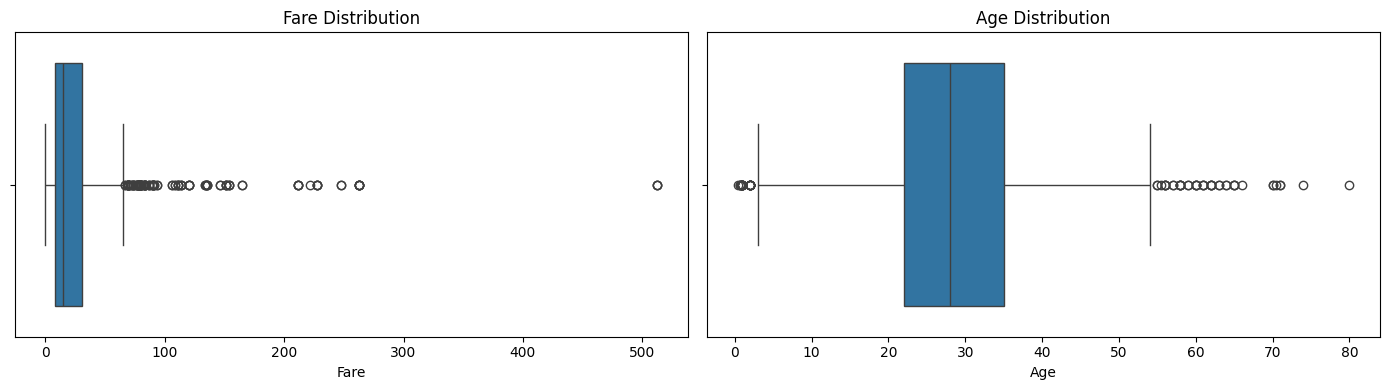

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=df["Fare"], ax=axes[0])
axes[0].set_title("Fare Distribution")
sns.boxplot(x=df["Age"], ax=axes[1])
axes[1].set_title("Age Distribution")
plt.tight_layout()
plt.show()

**Step 2 - IQR method:**

In [12]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

lower, upper = iqr_bounds(df["Fare"])
outliers = df[(df["Fare"] < lower) | (df["Fare"] > upper)]
print(f"Found {len(outliers)} Fare outliers")


Found 116 Fare outliers


**Step 3 - Cap at 99th percentile:**

In [13]:
df_original = df.copy()
cap_value = df["Fare"].quantile(0.99)
df["Fare"] = df["Fare"].clip(upper=cap_value)


**Step 4 - Before/after:**

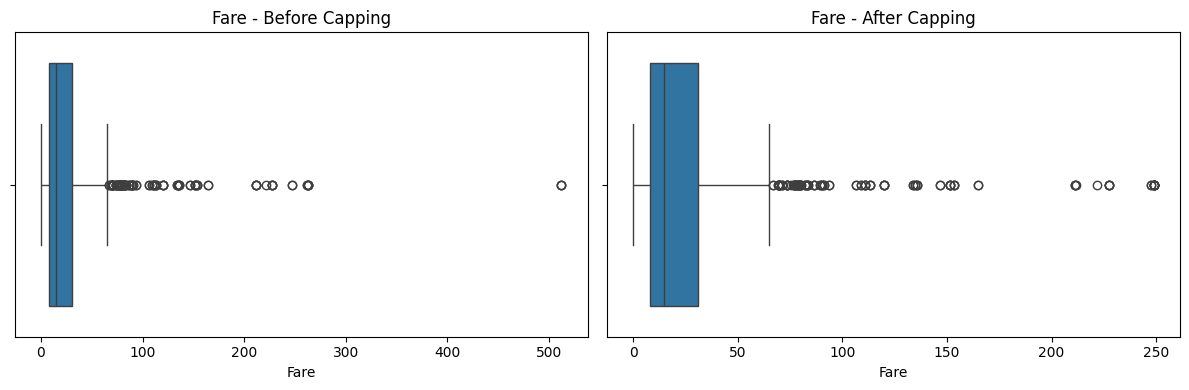

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_original["Fare"], ax=axes[0])
axes[0].set_title("Fare - Before Capping")
sns.boxplot(x=df["Fare"], ax=axes[1])
axes[1].set_title("Fare - After Capping")
plt.tight_layout()
plt.show()

Write `clean_data()` Function

In [15]:
def clean_data(df):
    """Full cleaning pipeline for Titanic dataset."""
    df = df.copy()

    # 1. Fix data types
    df["Survived"] = df["Survived"].astype("category")
    df["Pclass"] = df["Pclass"].astype("category")
    df["Sex"] = df["Sex"].astype("category")
    df["Embarked"] = df["Embarked"].astype("category")

    # 2. Drop Cabin (77% missing)
    df = df.drop(columns=["Cabin"])

    # 3. Handle missing values
    df["Age"] = df["Age"].fillna(df["Age"].median())
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    # 4. Remove duplicates
    df = df.drop_duplicates()

    # 5. Cap Fare outliers at 99th percentile
    cap = df["Fare"].quantile(0.99)
    df["Fare"] = df["Fare"].clip(upper=cap)

    return df


**Use it:**

In [16]:
df_raw = pd.read_csv("data/raw/train.csv")
df_clean = clean_data(df_raw)
df_clean.to_csv("data/cleaned/titanic_cleaned.csv", index=False)
print("Saved cleaned data:", df_clean.shape)

Saved cleaned data: (891, 11)


Add 3 Validation Checks

In [17]:
critical = ["Survived", "Pclass", "Sex", "Age", "Fare"]
for col in critical:
    assert df_clean[col].isnull().sum() == 0, f"Nulls found in {col}!"
print("Check 1 PASSED: No nulls in key columns")

assert df_clean["Survived"].isin([0, 1]).all(), "Invalid Survived values!"
print("Check 2 PASSED: All Survived values are 0 or 1")

assert "Cabin" not in df_clean.columns, "Cabin should have been dropped!"
assert df_clean.shape[1] >= 5, "Too few columns remaining!"
print("Check 3 PASSED: Column count OK, Cabin dropped")

Check 1 PASSED: No nulls in key columns
Check 2 PASSED: All Survived values are 0 or 1
Check 3 PASSED: Column count OK, Cabin dropped
